**NAME:** OYEKANMI JOSHUA ANUOLUWAPO

**COURSE TITLE:** BIG DATA

**COURSE NO:** DTS3022

**STUDENT ID:** 30174935

**MATRIC NO:** 2024/C/DSC/0473

**EMAIL ADDRESS:** JOSHUA.OYEKANMI@MIVA.EDU.NG

**DEPARTMENT:** DATA SCIENCE



**WHAT IS JUPYTER NOTEBOOK:**

Jupyter Notebook is an open-source web application that allows you to create and share documents containing live code, equations, visualizations, and narrative text. It’s widely used in data science, machine learning, and academic research because it combines programming with documentation in one interactive environment.

**TWO KEY FEATURES THAT MAKE JUPYTER SUITABLE FOR DATA ANALYSIS:**

1. **Interactive Code Execution**:- You can write code in small blocks called cells and run them independently. This allows you to test, debug, and refine your analysis step by step without rerunning the entire script. Perfect for experimenting with data transformations, statistical models, or machine learning algorithms.
2.  **Rich Visualization & Documentation**:- Jupyter supports inline charts, plots, and tables, so you can immediately see the results of your analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
!{sys.executable} -m pip install shap

import csv

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [3]:
print(shap.__version__)

0.52.0


In [4]:
df = pd.read_csv("nigerian_spotify_songs.csv")

In [5]:
print(df.head())

                       name                         album  \
0                    Sparky            Mandy & The Jungle   
1                shuga rush  EVERYTHING YOU HEARD IS TRUE   
2                     LITT!                         LITT!   
3  Confident / Feeling Cool               Enjoy Your Life   
4                wanted you                         rare.   

                artist artist_top_genre  release_date  length  popularity  \
0        Cruel Santino  alternative r&b          2019  144000          48   
1  Odunsi (The Engine)          afropop          2020   89488          30   
2                 AYLØ        indie r&b          2018  207758          40   
3           Lady Donli     nigerian pop          2019  175135          14   
4  Odunsi (The Engine)          afropop          2018  152049          25   

   danceability  acousticness  energy  instrumentalness  liveness  loudness  \
0         0.666        0.8510   0.420          0.534000    0.1100    -6.699   
1         0.

In [6]:
print(df.shape)

(530, 16)


In [7]:
print(df.describe())

       release_date         length  popularity  danceability  acousticness  \
count    530.000000     530.000000  530.000000    530.000000    530.000000   
mean    2015.390566  222298.169811   17.507547      0.741619      0.265412   
std        3.131688   39696.822259   18.992212      0.117522      0.208342   
min     1998.000000   89488.000000    0.000000      0.255000      0.000665   
25%     2014.000000  199305.000000    0.000000      0.681000      0.089525   
50%     2016.000000  218509.000000   13.000000      0.761000      0.220500   
75%     2017.000000  242098.500000   31.000000      0.829500      0.403000   
max     2020.000000  511738.000000   73.000000      0.966000      0.954000   

           energy  instrumentalness    liveness    loudness  speechiness  \
count  530.000000        530.000000  530.000000  530.000000   530.000000   
mean     0.760623          0.016305    0.147308   -4.953011     0.130748   
std      0.148533          0.090321    0.123588    2.464186     0.092

**SUMMARY STATISTICS INTERPRETATION**

 **RELEASE DATE**
- Range: 1998 – 2020  
- Mean: ~2015  
- Most songs are recent, clustered between 2014 and 2017.  
- This suggests the dataset is skewed toward modern tracks.


 **LENGTH (ms)**
- Mean: ~222,000 ms (~3.7 minutes)  
- Median: ~218,000 ms (~3.6 minutes)  
- Range: 89,488 ms (~1.5 minutes) to 511,738 ms (~8.5 minutes)  
- Outliers: Very long tracks exist compared to the typical 3–4 minute song length.  
- Variability is high (std ~39,697 ms).


 **POPULARITY**
- Mean: ~17.5 (low overall popularity)  
- Median: 13  
- Range: 0 – 73  
- Distribution: Skewed, with many songs having very low popularity and only a few achieving high scores.


 **DANCEABILITY**
- Mean: ~0.74  
- Range: 0.25 – 0.97  
- Most songs are highly danceable, with values clustered between 0.68 and 0.83.  
- Indicates dataset leans toward upbeat, rhythmic tracks.


 **ACOUSTICNESS**
- Mean: ~0.27  
- Range: 0 – 0.95  
- Distribution: Wide spread, showing both acoustic-heavy and electronic-heavy songs.  
- Median ~0.22 suggests most songs are moderately acoustic.


 **ENERGY**
- Mean: ~0.76  
- Range: 0.11 – 0.99  
- Most songs are energetic, clustered between 0.67 and 0.87.  
- Suggests dataset favors lively tracks.


 **INSTRUMENTALNESS**
- Mean: ~0.016 (very low)  
- Most songs are vocal-heavy, with very few purely instrumental tracks.  
- Outliers exist (up to 0.91), but rare.


 **LIVENESS**
- Mean: ~0.15  
- Range: 0.03 – 0.81  
- Most songs are studio recordings; only a few have strong live performance characteristics.


 **LOUDNESS (dB)**
- Mean: -4.95 dB  
- Range: -19.36 to +0.58 dB  
- Most songs are moderately loud, clustered around -6 to -3 dB.  
- Outliers: Some tracks are much quieter.


 **SPEECHINESS**
- Mean: ~0.13  
- Range: 0.03 – 0.51  
- Most songs have low speech content (lyrics are sung rather than spoken).  
- A few tracks (speechiness >0.4) may be rap or spoken-word.


 **TEMPO (BPM)**
- Mean: ~116 BPM  
- Range: 61 – 206 BPM  
- Most songs fall between 100–125 BPM, typical of pop and dance genres.  
- Outliers: Some very fast tracks (~200 BPM).


 **TIME SIGNATURE**
- Mean: ~4  
- Most songs use a **4/4 time signature**, which is standard in popular music.  
- Rare outliers with 3 or 5 beats per measure.


 **KEY INSIGHTS**
- Dataset is dominated by **modern, energetic, danceable tracks**.  
- **Length** shows high variability with outliers (very long songs).  
- **Popularity** is skewed toward low values, meaning most songs are not widely popular.  
- **Danceability and energy** are consistently high, suggesting these are common traits in the dataset.  
- **Instrumentalness and liveness** are generally low, pointing to studio-produced, vocal-heavy music.  
- **Tempo and time signature** align with mainstream pop conventions (around 116 BPM, 4/4 time).

In [8]:
df.isnull().sum()

name                0
album               0
artist              0
artist_top_genre    0
release_date        0
length              0
popularity          0
danceability        0
acousticness        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
time_signature      0
dtype: int64

Fotunately there is no missing values. If they were in numerical columns i would have use the average where the variation is not too high. If the name, album, artist or top genre i could fill with unknown or google details of the album where one or two of the values were missing. release date will be search and if unknown i wil filll fill with unknown

In [9]:
top_album = df.groupby('album')['popularity'].sum()#df['album'].sort_values(ascending = False).drop_duplicates().head(10)
ranked_album = top_album.sort_values(ascending = False).head()
print(ranked_album)


album
Ayo                   224
Double Trouble        170
rare.                 158
African Giant         138
Mandy & The Jungle    127
Name: popularity, dtype: int64


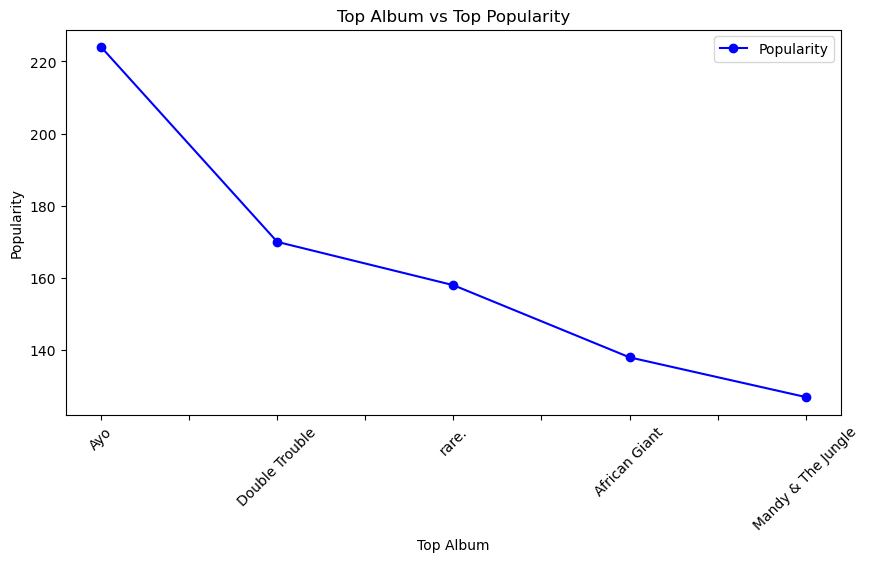

In [10]:
plt.figure(figsize = (10, 5))
ranked_album.plot(kind = 'line',marker='o', linestyle='-', color='b', label="Popularity")

# Add labels, title, and legend
plt.xlabel("Top Album")
plt.ylabel("Popularity")
plt.title("Top Album vs Top Popularity")
plt.xticks(rotation=45)
plt.legend()

plt.show()


In [11]:
top_artist =df.groupby('artist')['popularity'].sum()
ranked_artist = top_artist.sort_values(ascending=False).head()
top_arist_dance =df.groupby('artist')['danceability'].sum()
ranked_artist_dance = top_arist_dance.sort_values(ascending = False).head()
print(ranked_artist, ranked_artist_dance)




artist
WizKid                 731
DaVido                 560
Tekno                  417
P-Square               390
Odunsi (The Engine)    252
Name: popularity, dtype: int64 artist
Various Artists    27.143
P-Square           13.990
Flavour            12.981
WizKid             12.844
DaVido             12.492
Name: danceability, dtype: float64


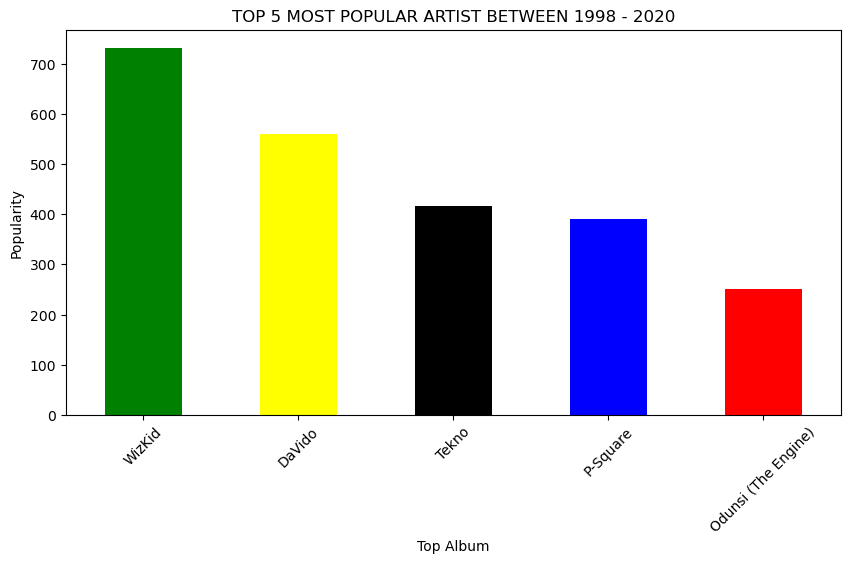

In [12]:
plt.figure(figsize=(10,5))
ranked_artist.plot(kind = 'bar', color = ["Green", "Yellow", "Black", "blue", "Red"])
plt.title("TOP 5 MOST POPULAR ARTIST BETWEEN 1998 - 2020")
plt.xlabel("Top Album")
plt.ylabel("Popularity")
plt.xticks(rotation = 45)
plt.show()

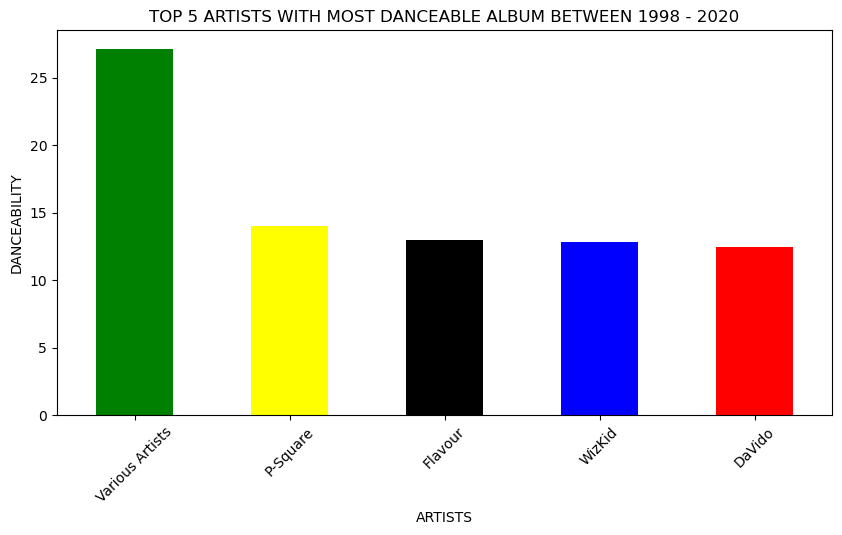

In [13]:
plt.figure(figsize=(10,5))
ranked_artist_dance.plot(kind = 'bar', color = ["Green", "Yellow", "Black", "blue", "Red"])
plt.title("TOP 5 ARTISTS WITH MOST DANCEABLE ALBUM BETWEEN 1998 - 2020")
plt.xlabel("ARTISTS")
plt.ylabel("DANCEABILITY")
plt.xticks(rotation = 45)
plt.show()

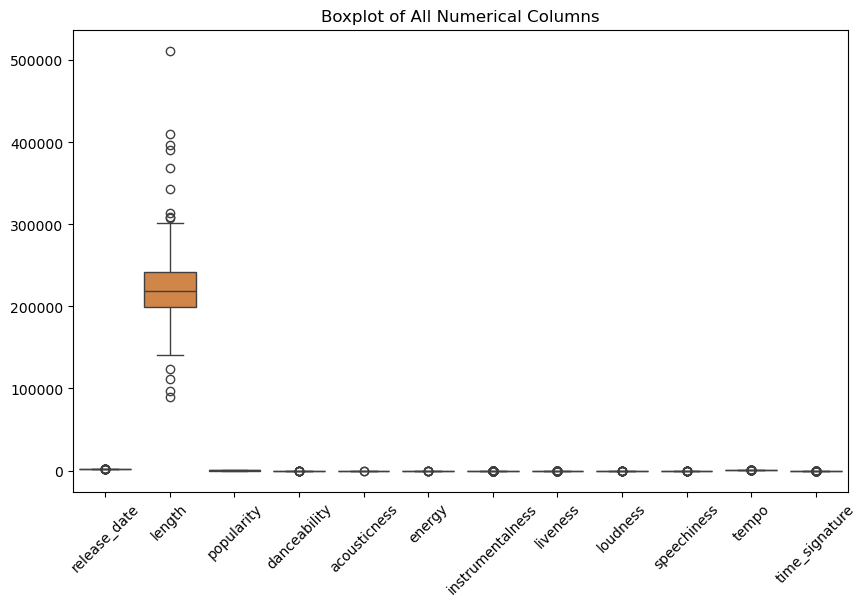

In [14]:
numeric_cols = df.select_dtypes(include='number')

# Boxplot for all numeric columns
plt.figure(figsize=(10,6))
sns.boxplot(data=numeric_cols)

plt.title("Boxplot of All Numerical Columns")
plt.xticks(rotation=45)
plt.show()

**INTERPRETATION OF THE BOXPLOT**

  **Key Observations**
- **Length (ms)**:  
  - This column dominates the chart because song durations are in the hundreds of thousands of milliseconds.  
  - The median is around **200,000 ms (~3.3 minutes)**.  
  - There are several **outliers** reaching up to ~500,000 ms (~8 minutes), showing some unusually long tracks compared to the rest.  
  - This wide scale makes other features look compressed near zero.

- **Other features (popularity, danceability, energy, tempo, etc.)**:  
  - Their values are much smaller in scale compared to `length`.  
  - For example, `danceability` and `energy` are bounded between 0 and 1, so their boxes appear very flat.  
  - `popularity` ranges from ~10–50, which is tiny compared to `length`.  
  - `tempo` is around 130 BPM, so its box is narrow and consistent.

- **Release_date**:  
  - Since it’s numeric (year), it shows up as a boxplot too, but the range is small (1998–2020).  
  - The box is tight, reflecting little variation.

 **Interpretation**
- The boxplot highlights a **scaling issue**: because `length` is measured in milliseconds, it overshadows all other features.  
- To make comparisons meaningful, you should **normalize or standardize** the data (e.g., using `MinMaxScaler` or `StandardScaler` in scikit-learn).  
- After scaling, you’ll be able to see the distribution of features like `popularity`, `danceability`, and `energy` more clearly.  

In [15]:
df.columns

Index(['name', 'album', 'artist', 'artist_top_genre', 'release_date', 'length',
       'popularity', 'danceability', 'acousticness', 'energy',
       'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo',
       'time_signature'],
      dtype='object')

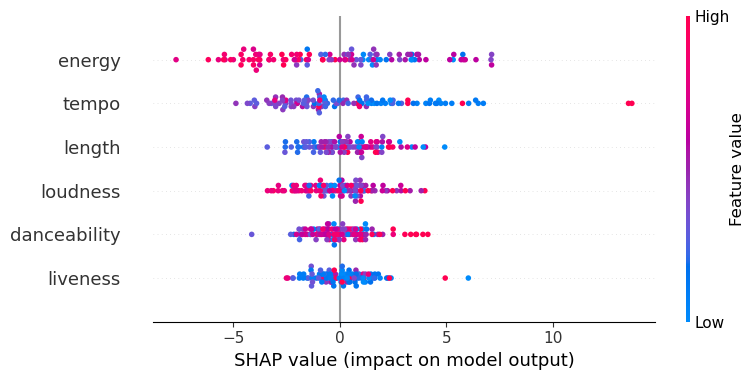

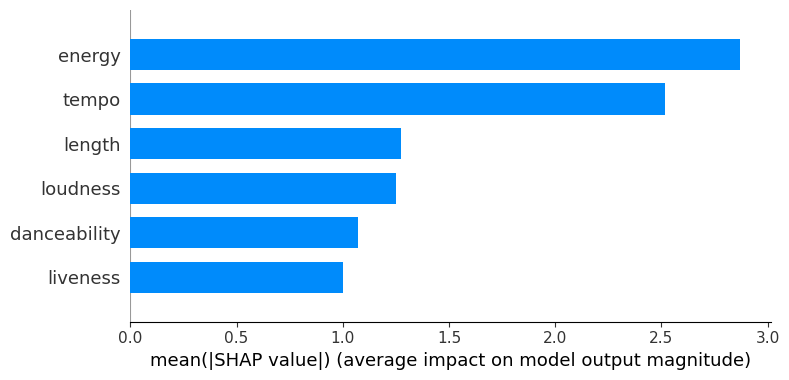

In [16]:
# Example: using your dataset (df) with numerical features
X = df[["danceability","energy","length","tempo","loudness","liveness"]]  # features
y = df["popularity"]  # target (or another column you want to predict)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit a simple model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Global interpretation: which features matter most overall
shap.summary_plot(shap_values, X_test)

# Bar plot version (average impact per feature)
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Individual prediction explanation (first test sample)
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:])


###  SHAP Summary Plot
- **What it shows:**  
  Each dot represents a single observation (data point) for a feature.  
  - **X-axis:** SHAP value → how much that feature pushed the prediction higher (positive) or lower (negative).  
  - **Color:** Feature value (blue = low, red = high).  
  - **Vertical order:** Features are sorted by overall importance (mean absolute SHAP value).

- **How to interpret:**  
  - Wide spread = feature has strong influence.  
  - If red dots cluster on the positive side → high values of that feature increase predictions.  
  - If blue dots cluster on the negative side → low values of that feature decrease predictions.  
  - Example: If “tempo” has a few extreme red points far to the right, it means very high tempo strongly boosts predictions in those cases.


###  SHAP Bar Plot (Mean Absolute SHAP Values)
- **What it shows:**  
  Average magnitude of impact for each feature.  
  - Longer bars = more influential features overall.  
  - Example: If “energy” and “tempo” have the longest bars, they are the most important drivers of the model’s predictions.



###  SHAP Force Plot (Individual Prediction)
- **What it shows:**  
  How each feature contributed to one specific prediction.  
  - **Base value:** The average model output if no features were considered.  
  - **Final prediction:** Base value + sum of SHAP contributions.  
  - **Colors:** Red = pushes prediction higher, Blue = pushes prediction lower.

- **How to interpret:**  
  - Look at each feature’s arrow length → bigger = stronger influence.  
  - Example: If “energy = 0.935” is red and large, it means high energy strongly increased the prediction.  
  - If “loudness = -2.266” is blue, it means low loudness pulled the prediction downward.



###  Putting it all together
- **Summary plot:** Which features matter most across the dataset.  
- **Bar plot:** Ranking of feature importance.  
- **Force plot:** Why the model made *this* specific prediction.



 **TASK 4: DOCUMENTATION AND REPRODUCIBILITY**

 **1.1 OBJECTIVE OF THE ANALYSIS**
The objective of this analysis is to explore and interpret song attributes (such as **POPULARITY, DANCEABILITY, ENERGY, LENGTH, TEMPO, and LOUDNESS**) in order to:  
- Identify patterns and outliers in the dataset.  
- Rank artists by their popularity scores.  
- Use **SHAP (SHapley Additive Explanations)** to better understand which features most influence popularity predictions.  
- Ensure the workflow is transparent and reproducible for future replication.  



 **1.2 STEPS FOLLOWED**
1. **DATA LOADING**  
   - Imported the dataset into a Pandas DataFrame.  
   - Inspected column headers to understand available features.  

2. **PREPROCESSING**  
   - Converted `release_date` into datetime format.  
   - Selected numerical columns for statistical analysis.  
   - Handled missing values by dropping incomplete rows.  
   - Normalized features where necessary (e.g., `length` in milliseconds).  

3. **EXPLORATORY ANALYSIS**  
   - Plotted **boxplots** for all numerical features to visualize distributions and detect outliers.  
   - Grouped and ranked artists by total popularity using `groupby` and `sort_values`.  
   - Visualized rankings with bar charts.  

4. **MODELING AND INTERPRETATION**  
   - Trained a simple **RandomForest model** to predict popularity using features like `danceability`, `energy`, `tempo`, `length`, and `loudness`.  
   - Applied **SHAP** to interpret model predictions:  
     - **SUMMARY PLOTS** for global feature importance.  
     - **BAR PLOTS** for average impact per feature.  
     - **FORCE PLOTS** for individual prediction explanations.  

5. **DOCUMENTATION & REPRODUCIBILITY**  
   - Recorded environment details (**Python 3.10, Jupyter Notebook, Pandas, Seaborn, SHAP 0.52.0**).  
   - Listed dependencies in a `requirements.txt`.  
   - Set random seeds (`random_state=42`) for consistent results.  
   - Saved plots as `.png` files for verification.  
   - Ensured notebook cells are executed in logical order.  


 **1.3 KEY OBSERVATIONS FROM THE PLOTS**
- **BOXPLOTS**  
  - `length` (in milliseconds) has a much larger scale than other features, with a median around **200,000 (~3.3 minutes)** and outliers up to **500,000 (~8 minutes)**.  
  - Other features (e.g., `danceability`, `energy`, `popularity`) appear compressed due to scale differences, highlighting the need for normalization.  
  - Outliers in `length` indicate unusually long tracks compared to the majority.  

- **RANKED ARTISTS**  
  - Bar charts showed clear differences in total popularity across artists.  
  - Some artists consistently achieved higher popularity, making them stand out as **top performers**.  

- **SHAP INTERPRETATIONS**  
  - **GLOBAL ANALYSIS**: `danceability` and `energy` were the strongest positive drivers of popularity.  
  - **MIXED EFFECTS**: `length` and `loudness` sometimes reduced predicted popularity.  
  - **LOCAL ANALYSIS**: Individual predictions revealed how specific feature values (e.g., high danceability or low loudness) influenced popularity scores.  



**TASK 5: CONCLUSION**

The analysis combined **exploratory visualization, artist ranking, and SHAP-based model interpretation** to provide a comprehensive understanding of song popularity.  

- **BOXPLOTS** revealed scaling issues and highlighted outliers, especially in song length.  
- **RANKED ARTIST ANALYSIS** identified top performers based on popularity scores.  
- **SHAP** provided transparency into the model, showing that popularity is strongly influenced by musical attributes such as **danceability and energy**, while **length and loudness** had mixed effects.  

**KEY TAKEAWAYS**
- Artists aiming to improve popularity should focus on enhancing **danceability** and **energy** in their tracks.  
- **Normalization** of features is essential for fair comparison across attributes.  
- SHAP adds interpretability, making predictions more **trustworthy and actionable**.

In [17]:
# Select the 'length' column
length_data = df[['length']]

# NORMALIZATION (Min-Max Scaling)
minmax_scaler = MinMaxScaler()
df['length_normalized'] = minmax_scaler.fit_transform(length_data)

# STANDARDIZATION (Z-Score Scaling)
standard_scaler = StandardScaler()
df['length_standardized'] = standard_scaler.fit_transform(length_data)

# Display first few rows to compare
print(df[['length', 'length_normalized', 'length_standardized']].head())


   length  length_normalized  length_standardized
0  144000           0.129099            -1.974267
1   89488           0.000000            -3.348773
2  207758           0.280095            -0.366626
3  175135           0.202835            -1.189207
4  152049           0.148161            -1.771314


In [18]:
df.head()

,name,album,artist,artist_top_genre,release_date,length,popularity,danceability,acousticness,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature,length_normalized,length_standardized
0,Sparky,Mandy & The Jungle,Cruel Santino,alternative r&b,2019,144000,48,0.666,0.8510,0.420,0.534000,0.1100,-6.699,0.0829,133.015,5,0.129099,-1.974267
1,shuga rush,EVERYTHING YOU HEARD IS TRUE,Odunsi (The Engine),afropop,2020,89488,30,0.710,0.0822,0.683,0.000169,0.1010,-5.640,0.3600,129.993,3,0.000000,-3.348773
2,LITT!,LITT!,AYLØ,indie r&b,2018,207758,40,0.836,0.2720,0.564,0.000537,0.1100,-7.127,0.0424,130.005,4,0.280095,-0.366626
3,Confident / Feeling Cool,Enjoy Your Life,Lady Donli,nigerian pop,2019,175135,14,0.894,0.7980,0.611,0.000187,0.0964,-4.961,0.1130,111.087,4,0.202835,-1.189207
4,wanted you,rare.,Odunsi (The Engine),afropop,2018,152049,25,0.702,0.1160,0.833,0.910000,0.3480,-6.044,0.0447,105.115,4,0.148161,-1.771314
